## Classificatore Solo-Sintetico — ResNet-50 con Fine-Tuning

Classificatore binario (cancro / non cancro) su mammografie con **ResNet-50** (ImageNet) e training in due fasi:

1. **Head Training** — backbone congelato, solo la custom head (GAP → Dense(256) → BN → LeakyReLU → Dropout(0.5) → sigmoid). Loss: `BinaryCrossentropy`, class weights bilanciati, Adam lr=1e-3.
2. **Fine-Tuning** — sblocco parziale del backbone da `conv4_block5_1_conv` (BN restano congelati). Loss: `BinaryFocalCrossentropy` (γ=2, α=0.75), Adam lr=1e-5 con ReduceLROnPlateau.

Valutazione con soglia ottimale (indice di Youden), metriche su validation set e Grad-CAM per l'interpretabilità.

I dati di train utilizzati per l'addestramento del modello sono solo dati sintetici realizzati dall'architettura diffusiva fine-tuning

In [1]:
import os
import sys

# Controlla se il notebook sta girando su Google Colab
if 'google.colab' in sys.modules:
    from google.colab import drive
    # Monta il drive
    drive.mount('/content/drive')
    
    # IMPORTANTE: Inserisci qui il percorso esatto della cartella su Drive.
    # Se è una cartella condivisa standard di cui avete creato una scorciatoia 
    # nel vostro Drive personale, il percorso sarà simile a questo:
    BASE_PATH = '/content/drive/MyDrive/MammoDiffusion/'
    
    # Se invece è un "Drive Condiviso" aziendale/universitario:
    # BASE_PATH = '/content/drive/Shareddrives/Nome_Drive/Nome_Progetto/'

else:
    print("Ambiente locale rilevato.")
    # Imposta la directory base in locale. 
    # './' significa la cartella in cui si trova attualmente il notebook.
    # Oppure usa '../' se i notebook sono in una sottocartella e i dati fuori.
    BASE_PATH = '../'

print(f"Percorso base: ", BASE_PATH)

Ambiente locale rilevato.
Percorso base:  ../


#### Import Librerie

In [2]:
import zipfile
import gdown
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import regularizers
from sklearn.utils.class_weight import compute_class_weight
from datetime import date

I0000 00:00:1781691449.079219    1241 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781691449.977657    1241 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781691452.981555    1241 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


#### Download immagini sintetiche (fine-tuned)

Scarica da Google Drive lo ZIP con le immagini sintetiche positive e negative, le estrae nelle rispettive cartelle e rimuove l'archivio.
Se le immagini sono già presenti in locale, il download viene saltato


In [3]:
DEST_DIR     = os.path.join(BASE_PATH, 'data', 'synthetic', 'fine_tuned')
DEST_DIR_POS = os.path.join(DEST_DIR, 'positive')
DEST_DIR_NEG = os.path.join(DEST_DIR, 'negative')
ZIP_PATH     = os.path.join(DEST_DIR, 'filtered_generated.zip')
SYNTHETIC_DRIVE_ID = '1NKXKcovSlS4-0_zznKmrg1nU0DiXhcFq'

# CONFIGURA QUI: nomi delle cartelle dentro lo ZIP
ZIP_FOLDER_POS = 'positive_filtered_1361_adaptive_mask'   # cartella nello ZIP che contiene le immagini POSITIVE (cancer=1)
ZIP_FOLDER_NEG = 'negative_filtered_1361_adaptive_mask'   # cartella nello ZIP che contiene le immagini NEGATIVE (cancer=0)

def synthetic_data_ready():
    if not os.path.isdir(DEST_DIR_POS) or not os.path.isdir(DEST_DIR_NEG):
        return False
    return (
        any(f.endswith('.png') for f in os.listdir(DEST_DIR_POS)) and
        any(f.endswith('.png') for f in os.listdir(DEST_DIR_NEG))
    )

os.makedirs(DEST_DIR, exist_ok=True)

if not synthetic_data_ready():
    import shutil, tempfile
    print("Immagini sintetiche non trovate, scarico da Google Drive...")
    gdown.download(id=SYNTHETIC_DRIVE_ID, output=ZIP_PATH, quiet=False)

    with tempfile.TemporaryDirectory() as tmp:
        with zipfile.ZipFile(ZIP_PATH, 'r') as z:
            z.extractall(tmp)
        shutil.move(os.path.join(tmp, ZIP_FOLDER_POS), DEST_DIR_POS)
        shutil.move(os.path.join(tmp, ZIP_FOLDER_NEG), DEST_DIR_NEG)

    os.remove(ZIP_PATH)
    n_pos = sum(1 for f in os.listdir(DEST_DIR_POS) if f.endswith('.png'))
    n_neg = sum(1 for f in os.listdir(DEST_DIR_NEG) if f.endswith('.png'))
    print(f"Estrazione completata. File presenti:\n - Positivi: {n_pos}\n - Negativi: {n_neg}")
else:
    n_pos = sum(1 for f in os.listdir(DEST_DIR_POS) if f.endswith('.png'))
    n_neg = sum(1 for f in os.listdir(DEST_DIR_NEG) if f.endswith('.png'))
    print(f"Immagini sintetiche già presenti:\n - Positivi: {n_pos}\n - Negativi: {n_neg}")

Immagini sintetiche già presenti:
 - Positivi: 1361
 - Negativi: 1361


#### Creazione CSV per dataset sintetico

In [ ]:
# Percorso del csv in output
OUTPUT_CSV = os.path.join(BASE_PATH, 'data', 'synthetic', 'metadata', 'train_synthetic_ft_dataset.csv')
os.makedirs(os.path.dirname(OUTPUT_CSV), exist_ok=True)

rows = []
for f in sorted(os.listdir(DEST_DIR_POS)):
    if f.endswith('.png'):
        rows.append({'processed_path': os.path.join(DEST_DIR_POS, f), 'cancer': 1})
for f in sorted(os.listdir(DEST_DIR_NEG)):
    if f.endswith('.png'):
        rows.append({'processed_path': os.path.join(DEST_DIR_NEG, f), 'cancer': 0})

df_synth = pd.DataFrame(rows, columns=['processed_path', 'cancer'])
df_synth.to_csv(OUTPUT_CSV, index=False)

n_pos = (df_synth.cancer == 1).sum()
n_neg = (df_synth.cancer == 0).sum()
print(f"CSV salvato in: {OUTPUT_CSV}")
print(f"Totale immagini: {len(df_synth)}  (cancer=1: {n_pos}, cancer=0: {n_neg})")

CSV salvato in: ../data/synthetic/metadata/train_synthetic_ft_dataset.csv
Totale immagini: 2722  (cancer=1: 1361, cancer=0: 1361)


#### Semplice Analisi Esplorativa Dataset Sintetico

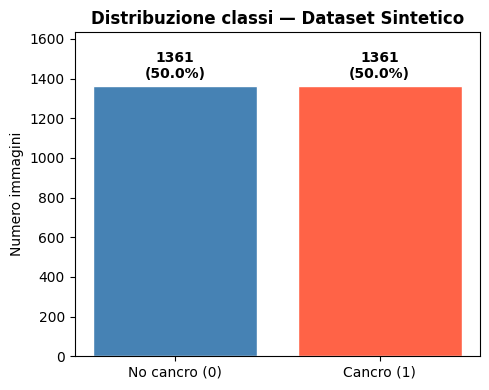

In [5]:
n_pos = (df_synth.cancer == 1).sum()
n_neg = (df_synth.cancer == 0).sum()
tot   = len(df_synth)

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(['No cancro (0)', 'Cancro (1)'], [n_neg, n_pos],
              color=['steelblue', 'tomato'], edgecolor='white')
ax.set_title('Distribuzione classi — Dataset Sintetico', fontweight='bold')
ax.set_ylabel('Numero immagini')
ax.set_ylim(0, max(n_neg, n_pos) * 1.2)
for bar, v in zip(bars, [n_neg, n_pos]):
    ax.text(bar.get_x() + bar.get_width() / 2, v + tot * 0.01,
            f"{v}\n({v/tot*100:.1f}%)", ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

#### Configurazione

In [6]:
# Cartella per salvare i modelli
OUTPUT_EXP_DIR = os.path.join(BASE_PATH, 'experiments', 'exp20260617_full_synth_resnet50_fine_tuned_batch_size_16')
os.makedirs(OUTPUT_EXP_DIR, exist_ok=True)
print(OUTPUT_EXP_DIR)

../experiments/exp20260617_full_synth_resnet50_fine_tuned_batch_size_16


In [ ]:
IMG_SIZE = (224, 224) # dimensione standard ResNet-50
BATCH_SIZE = 16
SEED = 42

# Medie e std di ImageNet
IMAGENET_MEAN = tf.constant([0.485, 0.456, 0.406])
IMAGENET_STD = tf.constant([0.229, 0.224, 0.225])

# Percorsi train csv e val csv
VAL_CSV_PATH = os.path.join(BASE_PATH, 'data', 'processed', 'metadata', "val.csv")
TRAIN_CSV_PATH = os.path.join(BASE_PATH, 'data', 'synthetic', 'metadata', "train_synthetic_ft_dataset.csv")

# Imposta il seed per la riproducibilità
keras.utils.set_random_seed(SEED)
print(TRAIN_CSV_PATH)
print(VAL_CSV_PATH)

I0000 00:00:1781691534.105294    1241 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3536 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


../data/synthetic/metadata/train_synthetic_ft_dataset.csv
../data/processed/metadata/val.csv


#### Preparazione Dataset e Pipeline di Input

Carica i CSV di train e validation, calcola i **pesi delle classi** (bilanciamento del dataset sbilanciato tra casi positivi e negativi) e costruisce la pipeline `tf.data`.

**Preprocessing applicato ad ogni immagine:**
- Decodifica in scala di grigi (1 canale) e resize a `IMG_SIZE`
- Normalizzazione in `[0, 1]` e replica su 3 canali
- Standardizzazione con media e deviazione standard ImageNet

**Data Augmentation** (opzionale, al momento disabilitata): flip orizzontale e variazione casuale di luminosità. Escluse rotazioni verticali e zoom per non introdurre artefatti irrealistici nelle mammografie.

In [ ]:
# Carica e filtra il CSV
df_train = pd.read_csv(TRAIN_CSV_PATH).reset_index(drop=True)
df_val = pd.read_csv(VAL_CSV_PATH).reset_index(drop=True)

# Calcola i pesi delle classi per il training
labels_train = df_train['cancer'].values
classes = np.unique(labels_train)
weights = compute_class_weight('balanced', classes=classes, y=labels_train)
class_weight_dict = dict(zip(classes.astype(int), weights))
print(f"Class Weights: {class_weight_dict}")

AUTOTUNE = tf.data.AUTOTUNE

def load_and_preprocess(path, label):
    raw = tf.io.read_file(path)
    img = tf.image.decode_image(raw, channels=1, expand_animations=False) # 1 solo canale colore
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    img = tf.repeat(img, repeats=3, axis=-1) # da 1 canale colore => 3 canali colore
    img = (img - IMAGENET_MEAN) / IMAGENET_STD
        
    return img, tf.cast(label, tf.float32)

def augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, max_delta=0.05)
    img = tf.clip_by_value(img, -3.0, 3.0)
    return img, label
# Niente rotazioni forti (nessuna rotazione verticale), nemmeno zoom

def make_dataset(df, shuffle=False, augment_data=False):
    paths = df['processed_path'].values
    labels = df['cancer'].values
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(df), seed=SEED)
    ds = ds.map(lambda p, l: load_and_preprocess(p, l), num_parallel_calls=AUTOTUNE)
    if augment_data:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)

    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

# Costruisci i dataset
train_ds = make_dataset(df_train, shuffle=True, augment_data=False) # Da mettere a True se vuoi data augmentation
val_ds = make_dataset(df_val, shuffle=False, augment_data=False) 

Class Weights: {0: 1.0, 1: 1.0}


#### Configurazione e Salvataggio dell'Esperimento

In [9]:
experiment_config = {
    "experiment_name": os.path.basename(OUTPUT_EXP_DIR),
    "date": date.today().isoformat(),
    "backbone": {
        "name": "ResNet-50",
        "weights": "imagenet",
        "input_shape": list(IMG_SIZE) + [3],
        "include_top": False,
    },
    "head": {
        "pooling": "GlobalAveragePooling2D",
        "dense_units": 256,
        "l2_regularization": 1e-4,
        "activation": "LeakyReLU(negative_slope=0.1)",
        "dropout": 0.5,
        "output": "Dense(1, sigmoid)",
    },
    "preprocessing": {
        "img_size": list(IMG_SIZE),
        "normalization": "ImageNet mean/std",
        "imagenet_mean": [0.485, 0.456, 0.406],
        "imagenet_std": [0.229, 0.224, 0.225],
    },
    "data": {
        "batch_size": BATCH_SIZE,
        "seed": SEED,
        "augmentation": False,
        "train_csv": TRAIN_CSV_PATH,
        "val_csv": VAL_CSV_PATH,
    },
    "phase1_head_training": {
        "optimizer": "Adam",
        "learning_rate": 1e-3,
        "loss": "binary_crossentropy",
        "max_epochs": 25,
        "early_stopping_monitor": "val_auc",
        "early_stopping_patience": 7,
        "class_weight": "balanced",
        "backbone_trainable": False,
    },
    "phase2_fine_tuning": {
        "optimizer": "Adam",
        "learning_rate": 1e-5,
        "loss": "BinaryFocalCrossentropy",
        "BinaryFocalCrossentropy_gamma": 2.0,
        "BinaryFocalCrossentropy_alpha": 0.75,
        "max_epochs": 30,
        "fine_tune_from_layer": "conv4_block5_1_conv",
        "early_stopping_monitor": "val_auc",
        "early_stopping_patience": 5,
        "early_stopping_min_delta": 1e-3,
        "reduce_lr_factor": 0.5,
        "reduce_lr_patience": 3,
        "min_lr": 1e-7,
        "class_weight": "none",
    },
}

config_path = os.path.join(OUTPUT_EXP_DIR, 'experiment_config.json')
with open(config_path, 'w') as f:
    json.dump(experiment_config, f, indent=2, ensure_ascii=False)
print(f"Configurazione esperimento salvata in: {config_path}")


Configurazione esperimento salvata in: ../experiments/exp20260617_full_synth_resnet50_fine_tuned_batch_size_16/experiment_config.json


#### Costruzione del Modello — Fase 1 (Head Training)

Il modello segue un'architettura **feature extractor + custom head**:

- **Backbone**: ResNet-50 pre-addestrato su ImageNet, congelato (`trainable=False`)
- **Head**: GlobalAveragePooling → Dense(256) con L2 + BatchNorm + LeakyReLU + Dropout(0.5) → uscita sigmoidea per classificazione binaria

`training=False` nel forward pass del backbone mantiene le sue BatchNorm in modalità inferenza anche durante il training, evitando di corrompere le statistiche apprese.

La funzione restituisce sia `model` che `base_model` per permettere lo sblocco selettivo dei layer nella fase di fine-tuning.


In [ ]:
def build_base_model():
    # Carica il backbone ResNet-50 pre-addestrato
    base_model = keras.applications.ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=IMG_SIZE + (3,)
    )
    
    # Congela il backbone per l'addestramento della Custom Head
    base_model.trainable = False
    
    # Costruzione dell'architettura completa
    inputs = keras.Input(shape=IMG_SIZE + (3,))
    
    x = base_model(inputs, training=False) 
    
    x = layers.GlobalAveragePooling2D()(x)
    
    x = layers.Dense(256, kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.1)(x)
    x = layers.Dropout(0.5)(x)
    
    # Sigmoide per classificazione binaria    
    outputs = layers.Dense(1, activation='sigmoid')(x)
    
    model = keras.Model(inputs, outputs, name="full_synth_resnet50")
    return model, base_model

model, base_model = build_base_model()
model.summary()


Model: "full_synth_resnet50"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,113,537 (91.99 MB)

 Trainable params: 525,313 (2.00 MB)

 Non-trainable params: 23,588,224 (89.98 MB)

#### Compilazione e Training — Fase 1 (Head Training)

Il backbone rimane congelato: si addestrano solo i layer della custom head.

- **Loss**: `binary_crossentropy` — classificazione binaria (cancro / non cancro)
- **Metrica principale**: AUC — più robusta dell'accuracy su dataset sbilanciati
- **Class weight**: penalizza gli errori sulla classe minoritaria (casi positivi)
- **Early stopping**: patience 7 epoche su `val_auc`


In [11]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.AUC(name='auc'),
        keras.metrics.Recall(name='recall'),
        keras.metrics.Precision(name='precision')
    ]
)

callbacks_fase1 = [
    keras.callbacks.EarlyStopping(
        monitor='val_auc',
        patience=7,
        restore_best_weights=True,
        mode='max'
    ),
    keras.callbacks.ModelCheckpoint(
        os.path.join(OUTPUT_EXP_DIR, 'full_synth_resnet50_fase1_best.keras'),
        monitor='val_auc',
        save_best_only=True,
        mode='max'
    ),
    keras.callbacks.CSVLogger(
        os.path.join(OUTPUT_EXP_DIR, 'training_log_fase1.csv'),
        separator=',',
        append=False
    )
]

history_phase1 = model.fit(
    train_ds,
    epochs=25,
    validation_data=val_ds,
    class_weight=class_weight_dict,
    callbacks=callbacks_fase1
)

Epoch 1/25


I0000 00:00:1781691639.615808    1751 service.cc:153] XLA service 0x7e6d6006c6d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781691639.615849    1751 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.22.0)
I0000 00:00:1781691640.380064    1751 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1781691643.149537    1751 cuda_dnn.cc:461] Loaded cuDNN version 92200
I0000 00:00:1781691643.336306    1751 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_12190__.197
I0000 00:00:1781691654.284862    1751 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


169/171 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5319 - auc: 0.5437 - loss: 0.8662 - precision: 0.5088 - recall: 0.4912

I0000 00:00:1781691663.043959    1752 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_12190__.197


171/171 ━━━━━━━━━━━━━━━━━━━━ 55s 186ms/step - accuracy: 0.5503 - auc: 0.5670 - loss: 0.8247 - precision: 0.5497 - recall: 0.5569 - val_accuracy: 0.6247 - val_auc: 0.5477 - val_loss: 0.6784 - val_precision: 0.1679 - val_recall: 0.3151
Epoch 2/25
171/171 ━━━━━━━━━━━━━━━━━━━━ 8s 47ms/step - accuracy: 0.5720 - auc: 0.5988 - loss: 0.7636 - precision: 0.5709 - recall: 0.5797 - val_accuracy: 0.6133 - val_auc: 0.5250 - val_loss: 0.6805 - val_precision: 0.1418 - val_recall: 0.2603
Epoch 3/25
171/171 ━━━━━━━━━━━━━━━━━━━━ 9s 54ms/step - accuracy: 0.5966 - auc: 0.6325 - loss: 0.7275 - precision: 0.5962 - recall: 0.5988 - val_accuracy: 0.5789 - val_auc: 0.5347 - val_loss: 0.7829 - val_precision: 0.1716 - val_recall: 0.3973
Epoch 4/25
171/171 ━━━━━━━━━━━━━━━━━━━━ 9s 50ms/step - accuracy: 0.6113 - auc: 0.6512 - loss: 0.7039 - precision: 0.6089 - recall: 0.6223 - val_accuracy: 0.5355 - val_auc: 0.4943 - val_loss: 0.7603 - val_precision: 0.1348 - val_recall: 0.3288
Epoch 5/25
171/171 ━━━━━━━━━━━━━━━━━━

W0000 00:00:1781691835.120668    2140 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 16777600 bytes after encountering the first element of size 16777600 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


171/171 ━━━━━━━━━━━━━━━━━━━━ 8s 49ms/step - accuracy: 0.6583 - auc: 0.7214 - loss: 0.6458 - precision: 0.6479 - recall: 0.6936 - val_accuracy: 0.5789 - val_auc: 0.5719 - val_loss: 0.7385 - val_precision: 0.2032 - val_recall: 0.5205
Epoch 19/25
171/171 ━━━━━━━━━━━━━━━━━━━━ 8s 48ms/step - accuracy: 0.6697 - auc: 0.7289 - loss: 0.6408 - precision: 0.6587 - recall: 0.7046 - val_accuracy: 0.5858 - val_auc: 0.5734 - val_loss: 0.7757 - val_precision: 0.2033 - val_recall: 0.5068
Epoch 20/25
171/171 ━━━━━━━━━━━━━━━━━━━━ 9s 50ms/step - accuracy: 0.6576 - auc: 0.7191 - loss: 0.6490 - precision: 0.6512 - recall: 0.6789 - val_accuracy: 0.5057 - val_auc: 0.5658 - val_loss: 0.9021 - val_precision: 0.2033 - val_recall: 0.6712
Epoch 21/25
171/171 ━━━━━━━━━━━━━━━━━━━━ 10s 49ms/step - accuracy: 0.6543 - auc: 0.7182 - loss: 0.6480 - precision: 0.6479 - recall: 0.6760 - val_accuracy: 0.5332 - val_auc: 0.5596 - val_loss: 0.8597 - val_precision: 0.1953 - val_recall: 0.5753
Epoch 22/25
171/171 ━━━━━━━━━━━━━━━

#### Fine-Tuning — Fase 2 (Sblocco Parziale del Backbone)

Il backbone viene parzialmente sbloccato a partire da `conv4_block5_1_conv` (ultimi blocchi di ResNet-50),
mentre i layer precedenti e tutti i BatchNorm restano congelati per preservare le statistiche ImageNet.

- **Loss**: `BinaryFocalCrossentropy` — penalizza gli esempi difficili (`gamma=2`) e bilancia le classi (`alpha=0.75` al cancro)
- **class_weight rimosso**: il bilanciamento è già gestito da `apply_class_balancing=True`; applicarli insieme duplicherebbe la correzione
- **LR = 1e-5**: ordine di grandezza inferiore alla fase 1 per aggiornamenti graduali sui pesi pre-addestrati
- **ReduceLROnPlateau**: dimezza il LR se `val_auc` non migliora per 3 epoche, fino a un minimo di `1e-7`


In [ ]:
base_model.trainable = True
set_trainable = False

for layer in base_model.layers:
    if layer.name == 'conv4_block5_1_conv':
        set_trainable = True
    layer.trainable = set_trainable

# Freeze dei BatchNorm: anche nei layer sbloccati,
# le statistiche BN restano quelle di ImageNet
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

print(f"Totale layer nel base_model: {len(base_model.layers)}")
n_trainable_layers = sum(1 for l in base_model.layers if l.trainable)
print(f"Layer trainable nel base_model: {n_trainable_layers}/{len(base_model.layers)}")

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5), # Learning Rate basso per non distruggere i pesi ImageNet nei layer sbloccati
    loss=keras.losses.BinaryFocalCrossentropy(
        apply_class_balancing=True,
        alpha=0.75, # Peso alla classe positiva (cancer): 0.75 vs 0.25 per i negativi
        gamma=2.0, # Riduce il peso degli esempi già ben classificati
        from_logits=False
    ),
    metrics=[
        'accuracy',
        keras.metrics.AUC(name='auc'),
        keras.metrics.Recall(name='recall'),
        keras.metrics.Precision(name='precision')
    ]
)

callbacks_fase2 = [
    keras.callbacks.EarlyStopping(
        monitor='val_auc',
        patience=5,
        min_delta=1e-3,
        restore_best_weights=True,
        mode='max'
    ),
    keras.callbacks.ModelCheckpoint(
        os.path.join(OUTPUT_EXP_DIR, 'full_synth_resnet50_final_best.keras'),
        monitor='val_auc',
        save_best_only=True,
        mode='max'
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_auc',
        factor=0.5,
        patience=3,
        mode='max',
        min_lr=1e-7
    ),
    keras.callbacks.CSVLogger(
        os.path.join(OUTPUT_EXP_DIR, 'training_log_fase2.csv'),
        separator=',',
        append=False
    )
]

history_phase2 = model.fit(
    train_ds,
    epochs=30,
    validation_data=val_ds,
    #class_weight=class_weight_dict,
    callbacks=callbacks_fase2
)

print(f"\nTraining completato. Il miglior modello è salvato in: {os.path.join(OUTPUT_EXP_DIR, 'full_synth_resnet50_final_best.keras')}")


Totale layer nel base_model: 175
Layer trainable nel base_model: 36/175
Epoch 1/30


I0000 00:00:1781691926.586397    1749 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_76170__.197


170/171 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.6178 - auc: 0.6597 - loss: 0.1320 - precision: 0.6011 - recall: 0.6719

I0000 00:00:1781691952.486122    1748 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_76170__.197


171/171 ━━━━━━━━━━━━━━━━━━━━ 68s 232ms/step - accuracy: 0.6146 - auc: 0.6578 - loss: 0.1296 - precision: 0.6030 - recall: 0.6708 - val_accuracy: 0.2746 - val_auc: 0.5858 - val_loss: 0.2131 - val_precision: 0.1823 - val_recall: 0.9589 - learning_rate: 1.0000e-05
Epoch 2/30
171/171 ━━━━━━━━━━━━━━━━━━━━ 12s 68ms/step - accuracy: 0.6492 - auc: 0.7114 - loss: 0.1132 - precision: 0.6239 - recall: 0.7509 - val_accuracy: 0.3684 - val_auc: 0.5803 - val_loss: 0.2755 - val_precision: 0.1896 - val_recall: 0.8493 - learning_rate: 1.0000e-05
Epoch 3/30
171/171 ━━━━━━━━━━━━━━━━━━━━ 14s 84ms/step - accuracy: 0.6727 - auc: 0.7285 - loss: 0.1094 - precision: 0.6384 - recall: 0.7965 - val_accuracy: 0.4737 - val_auc: 0.6250 - val_loss: 0.1472 - val_precision: 0.2145 - val_recall: 0.8082 - learning_rate: 1.0000e-05
Epoch 4/30
171/171 ━━━━━━━━━━━━━━━━━━━━ 12s 71ms/step - accuracy: 0.6910 - auc: 0.7652 - loss: 0.1026 - precision: 0.6486 - recall: 0.8339 - val_accuracy: 0.3570 - val_auc: 0.5985 - val_loss: 0.

#### Visualizzazione Curve di Training

Plot Loss e AUC (train vs validation) per entrambe le fasi, salvati in `figures/`.

Analisi Overfitting - Fase 1 (Feature Extraction):
Grafico salvato in: ../experiments/exp20260617_full_synth_resnet50_fine_tuned_batch_size_16/figures/training_history_fase1.png


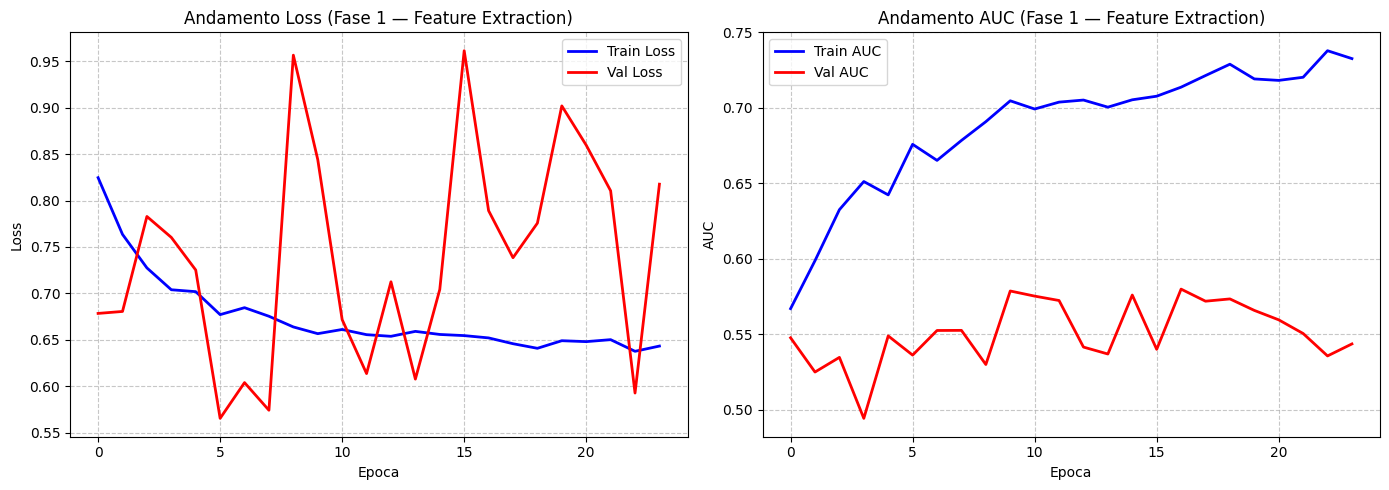

Analisi Overfitting - Fase 2 (Fine Tuning):
Grafico salvato in: ../experiments/exp20260617_full_synth_resnet50_fine_tuned_batch_size_16/figures/training_history_fase2.png


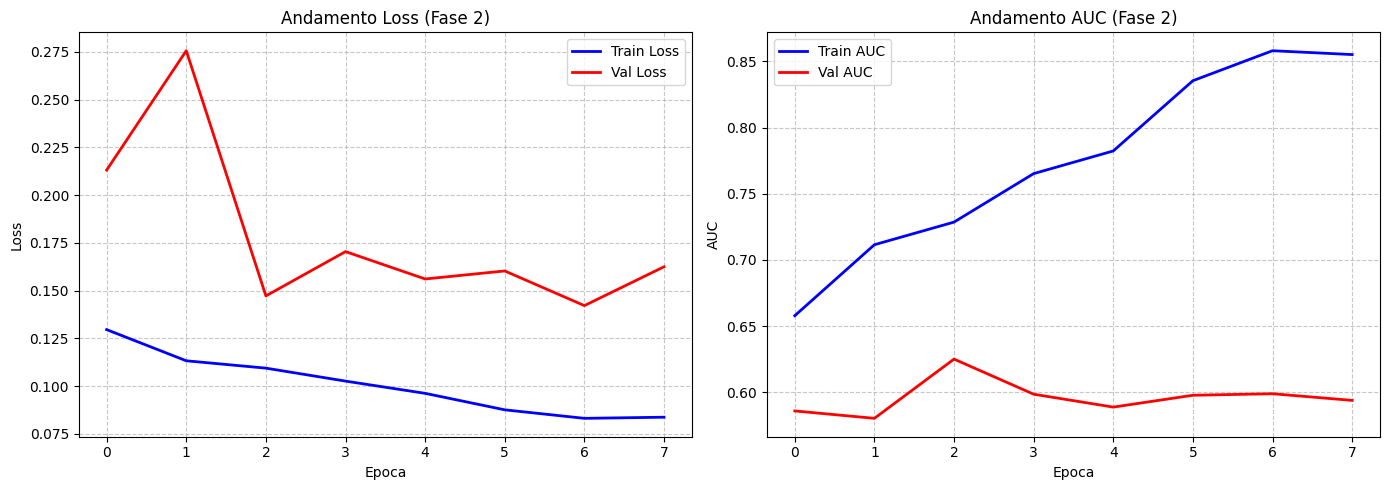

In [13]:
def plot_training_history(history, title_suffix="", save_path=None):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(history.history['loss'], label='Train Loss', color='blue', linewidth=2)
    ax1.plot(history.history['val_loss'], label='Val Loss', color='red', linewidth=2)
    ax1.set_title(f'Andamento Loss {title_suffix}')
    ax1.set_xlabel('Epoca')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.7)

    ax2.plot(history.history['auc'], label='Train AUC', color='blue', linewidth=2)
    ax2.plot(history.history['val_auc'], label='Val AUC', color='red', linewidth=2)
    ax2.set_title(f'Andamento AUC {title_suffix}')
    ax2.set_xlabel('Epoca')
    ax2.set_ylabel('AUC')
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Grafico salvato in: {save_path}")
    plt.show()

FIGURES_DIR = os.path.join(OUTPUT_EXP_DIR, 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)

print("Analisi Overfitting - Fase 1 (Feature Extraction):")
plot_training_history(
    history_phase1, "(Fase 1 — Feature Extraction)",
    save_path=os.path.join(FIGURES_DIR, 'training_history_fase1.png')
)

print("Analisi Overfitting - Fase 2 (Fine Tuning):")
plot_training_history(
    history_phase2, "(Fase 2)",
    save_path=os.path.join(FIGURES_DIR, 'training_history_fase2.png')
)

#### Valutazione sul Validation Set

Carica il miglior modello salvato e calcola le predizioni sull'intero validation set

- **Soglia ottimale**: determinata con l'indice di Youden (massimizza sensibilità + specificità), più adatta della soglia fissa 0.5 su dataset sbilanciati. Bilancia meglio i falsi negativi (tumori mancati) e falsi positivi
- **Metriche**: AUC, precision, recall e F1 calcolate sulla classe positiva (cancro) e salvate in `val_metrics.json`
- **Figure**: Confusion Matrix e ROC Curve salvate in `figures/`


AUC: 0.6244
Soglia ottimale: 0.516
              precision    recall  f1-score   support

   No cancro       0.91      0.44      0.59       364
      Cancro       0.22      0.79      0.35        73

    accuracy                           0.50       437
   macro avg       0.57      0.62      0.47       437
weighted avg       0.80      0.50      0.55       437

Metriche salvate in: ../experiments/exp20260617_full_synth_resnet50_fine_tuned_batch_size_16/val_metrics.json


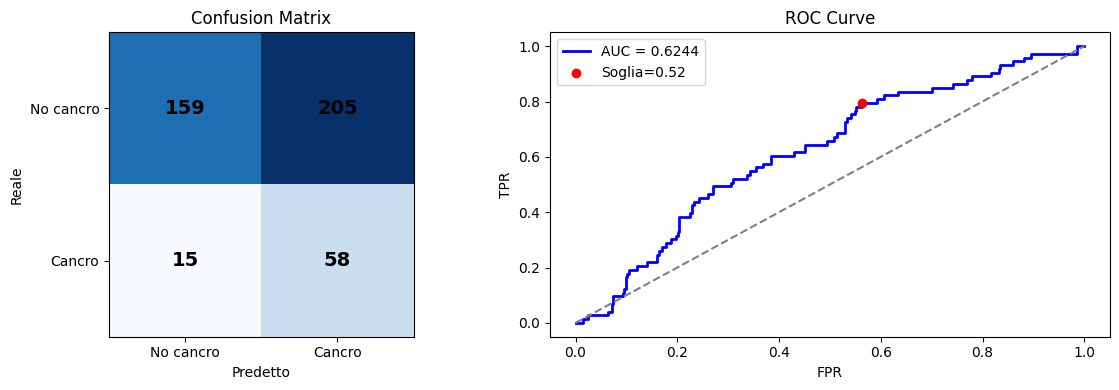

Figura salvata in: ../experiments/exp20260617_full_synth_resnet50_fine_tuned_batch_size_16/figures/val_confusion_roc.png


In [14]:
from sklearn.metrics import (confusion_matrix, roc_curve,
                             classification_report, roc_auc_score,
                             precision_score, recall_score, f1_score)

# Carica il miglior modello salvato
best_model = keras.models.load_model(
    os.path.join(OUTPUT_EXP_DIR, 'full_synth_resnet50_final_best.keras')
)

# Predizioni sul validation set
y_true, y_pred_prob = [], []
for imgs, labels in val_ds:
    preds = best_model.predict(imgs, verbose=0)
    y_pred_prob.extend(preds.flatten())
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred_prob = np.array(y_pred_prob)

# Soglia ottimale (Youden's J)
fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob)
youden_idx = np.argmax(tpr - fpr)
best_threshold = thresholds[youden_idx]
y_pred = (y_pred_prob >= best_threshold).astype(int)

val_auc = roc_auc_score(y_true, y_pred_prob)
report_str = classification_report(y_true, y_pred, target_names=['No cancro', 'Cancro'])

print(f"AUC: {val_auc:.4f}")
print(f"Soglia ottimale: {best_threshold:.3f}")
print(report_str)

# Salva metriche in JSON
FIGURES_DIR = os.path.join(OUTPUT_EXP_DIR, 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)

metrics_dict = {
    'split': 'validation',
    'backbone': 'ResNet-50',
    'experiment_name': os.path.basename(OUTPUT_EXP_DIR),
    'auc': round(float(val_auc), 4),
    'optimal_threshold_youden': round(float(best_threshold), 4),
    'accuracy': round(float((y_pred == y_true).mean()), 4),
    'precision_cancer': round(float(precision_score(y_true, y_pred, pos_label=1, zero_division=0)), 4),
    'recall_cancer':    round(float(recall_score(y_true, y_pred, pos_label=1, zero_division=0)), 4),
    'f1_cancer':        round(float(f1_score(y_true, y_pred, pos_label=1, zero_division=0)), 4),
    'classification_report': report_str,
}
metrics_path = os.path.join(OUTPUT_EXP_DIR, 'val_metrics.json')
with open(metrics_path, 'w') as f:
    json.dump(metrics_dict, f, indent=2, ensure_ascii=False)
print(f"Metriche salvate in: {metrics_path}")

# Figura: Confusion Matrix + ROC curve
cm = confusion_matrix(y_true, y_pred)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].imshow(cm, cmap='Blues')
axes[0].set_xticks([0, 1]); axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['No cancro', 'Cancro'])
axes[0].set_yticklabels(['No cancro', 'Cancro'])
axes[0].set_xlabel('Predetto'); axes[0].set_ylabel('Reale')
axes[0].set_title('Confusion Matrix')
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm[i, j], ha='center', va='center', fontsize=14, fontweight='bold')

axes[1].plot(fpr, tpr, color='blue', lw=2, label=f'AUC = {val_auc:.4f}')
axes[1].plot([0, 1], [0, 1], '--', color='gray')
axes[1].scatter(fpr[youden_idx], tpr[youden_idx], color='red', zorder=5, label=f'Soglia={best_threshold:.2f}')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('ROC Curve'); axes[1].legend()

plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, 'val_confusion_roc.png')
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Figura salvata in: {fig_path}")

#### Grad-CAM — Interpretabilità del Modello

Visualizza le regioni dell'immagine che hanno maggiormente influenzato la predizione, calcolando i gradienti dell'output rispetto alle feature map finali del backbone.

Per ogni campione vengono mostrati: immagine originale con heatmap sovrapposta e heatmap isolata.
Utile per verificare che il modello si concentri su aree anatomicamente rilevanti anziché su artefatti.


Modello caricato: full_synth_resnet50


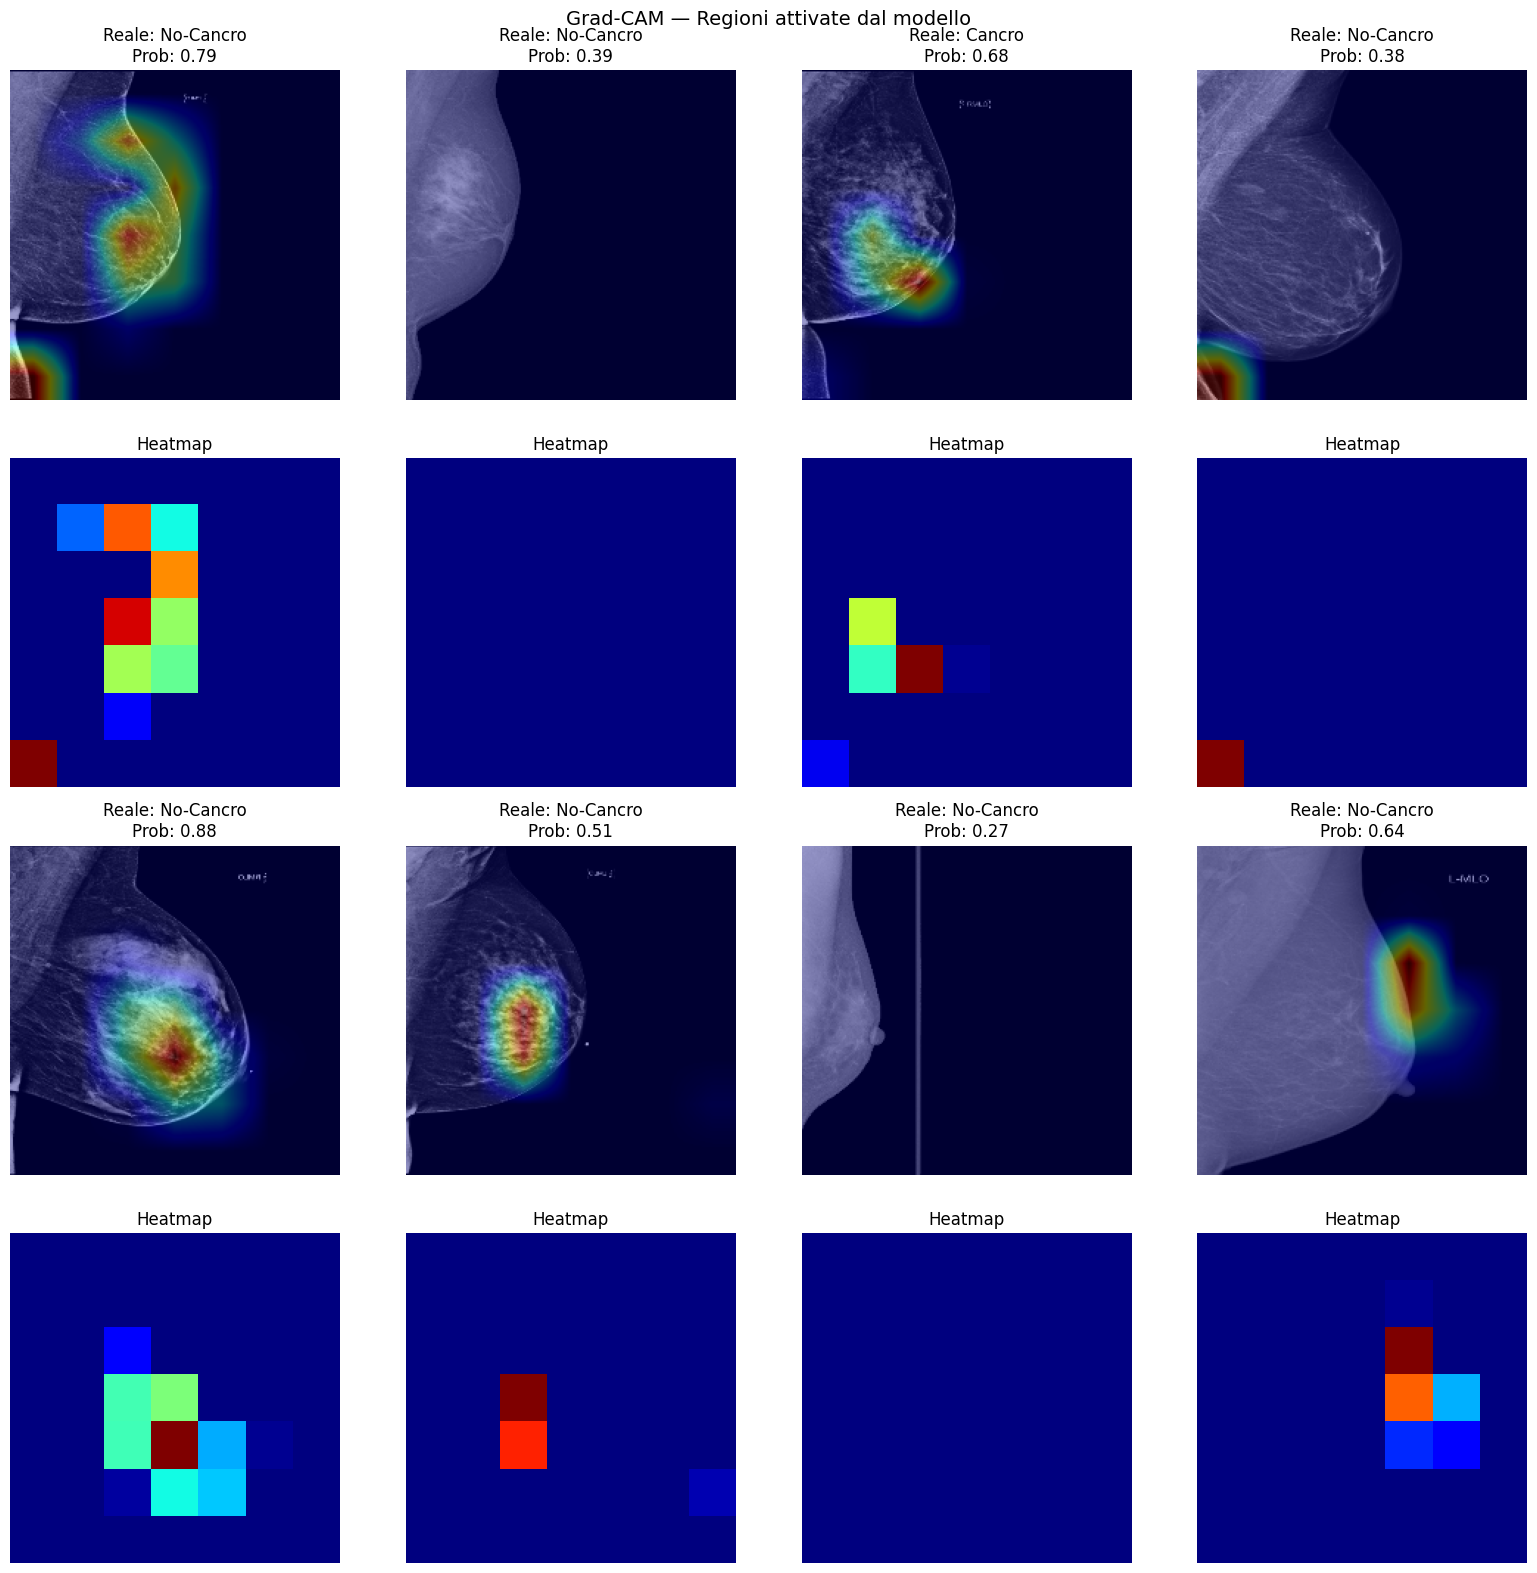

Grad-CAM salvato in: ../experiments/exp20260617_full_synth_resnet50_fine_tuned_batch_size_16/figures/gradcam_examples.png


In [ ]:
# Carica il modello già allenato
FIGURES_DIR = os.path.join(OUTPUT_EXP_DIR, 'figures')

best_model = keras.models.load_model(
    os.path.join(OUTPUT_EXP_DIR, 'full_synth_resnet50_final_best.keras')
)
print(f"Modello caricato: {best_model.name}")


def make_gradcam_heatmap(img_array, model):
    backbone = model.get_layer('resnet50')
    head_layers = [l for l in model.layers
                   if l.name not in [model.layers[0].name, backbone.name]]

    with tf.GradientTape() as tape:
        backbone_out = backbone(img_array, training=False) 
        tape.watch(backbone_out)
        x = backbone_out
        for layer in head_layers:
            x = layer(x, training=False)
        predictions = x

    grads = tape.gradient(predictions, backbone_out)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = backbone_out[0] @ pooled_grads[..., tf.newaxis] # Combinazione pesata delle feature map: canali più rilevanti contribuiscono di più
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()



def show_gradcam(img_tensor, heatmap, ax, title=""):
    img_vis = img_tensor.numpy() * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
    img_vis = np.clip(img_vis, 0, 1)
    img_vis_gray = img_vis[:, :, 0]  # canale singolo (mammografia)

    heatmap_resized = tf.image.resize(heatmap[..., np.newaxis], IMG_SIZE).numpy().squeeze()
    ax.imshow(img_vis_gray, cmap='gray')
    ax.imshow(heatmap_resized, cmap='jet', alpha=0.4)
    ax.set_title(title)
    ax.axis('off')


# Mostra Grad-CAM su 8 esempi del validation set
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
sample_count = 0
for imgs, labels in val_ds:
    for i in range(len(imgs)):
        if sample_count >= 8:
            break
        img = imgs[i:i+1]
        label = int(labels[i].numpy())
        prob = float(best_model.predict(img, verbose=0)[0][0])
        heatmap = make_gradcam_heatmap(img, best_model)

        row_img = (sample_count // 4) * 2       
        row_heat = row_img + 1                  
        col = sample_count % 4                  

        show_gradcam(imgs[i], heatmap, axes[row_img, col],
                     title=f"Reale: {'Cancro' if label==1 else 'No-Cancro'}\nProb: {prob:.2f}")
        axes[row_heat, col].imshow(heatmap, cmap='jet')
        axes[row_heat, col].set_title("Heatmap")
        axes[row_heat, col].axis('off')
        sample_count += 1
    if sample_count >= 8:
        break

plt.suptitle("Grad-CAM — Regioni attivate dal modello", fontsize=14)
plt.tight_layout()
gradcam_path = os.path.join(FIGURES_DIR, 'gradcam_examples.png')
fig.savefig(gradcam_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Grad-CAM salvato in: {gradcam_path}")

#### Grad-CAM su immagini sintetiche

Applica Grad-CAM a 8 immagini sintetiche campionate casualmente (seed fisso).
Per ogni campione mostra immagine originale con heatmap sovrapposta e heatmap isolata, organizzate in una griglia 4×4 (riga pari = immagine, riga dispari = heatmap).

Permette di verificare se il modello attiva regioni anatomicamente plausibili anche sulle immagini generate, validando la qualità delle sintetiche dal punto di vista del classificatore.


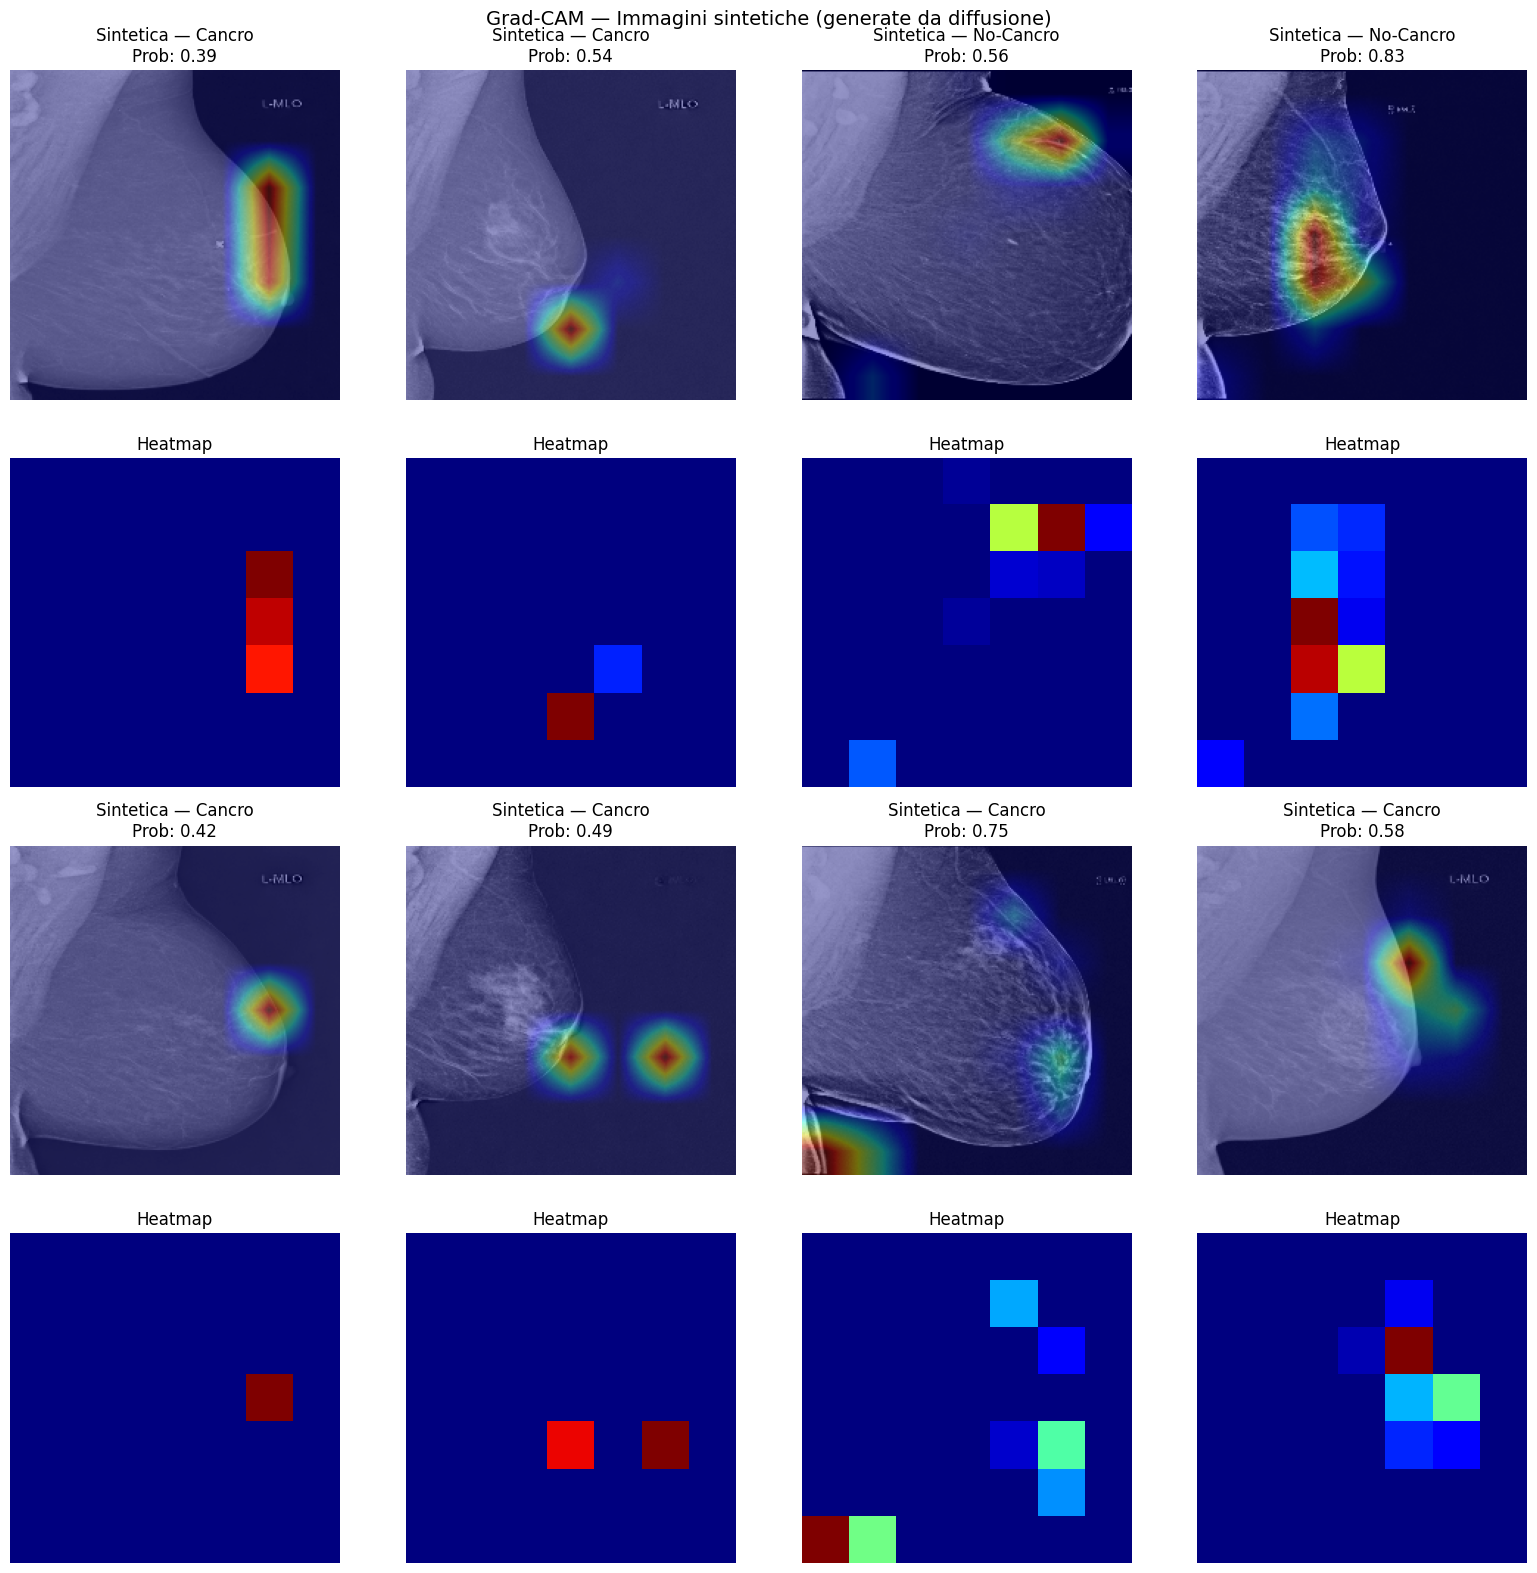

Grad-CAM sintetiche salvato in: ../experiments/exp20260617_full_synth_resnet50_fine_tuned_batch_size_16/figures/gradcam_synthetic_examples.png


In [ ]:
# Dataset con sole immagini sintetiche
synth_ds = make_dataset(df_synth[['processed_path', 'cancer']], shuffle=False, augment_data=False)

# Raccoglie tutte le immagini sintetiche e campiona 8 casuali
all_synth_imgs, all_synth_labels = [], []
for imgs, labels in synth_ds:
    for i in range(len(imgs)):
        all_synth_imgs.append(imgs[i])
        all_synth_labels.append(int(labels[i].numpy()))

np.random.seed(SEED)  # per avere riproducibilità
indices_synth = np.random.choice(len(all_synth_imgs), size=8, replace=False)

fig, axes = plt.subplots(4, 4, figsize=(16, 16))
for i, idx in enumerate(indices_synth):
    img = tf.expand_dims(all_synth_imgs[idx], 0)
    label = all_synth_labels[idx]
    prob = float(best_model.predict(img, verbose=0)[0][0])
    heatmap = make_gradcam_heatmap(img, best_model)

    row_img = (i // 4) * 2       
    row_heat = row_img + 1       
    col = i % 4                 

    show_gradcam(all_synth_imgs[idx], heatmap, axes[row_img, col],
                 title=f"Sintetica — {'Cancro' if label==1 else 'No-Cancro'}\nProb: {prob:.2f}")
    axes[row_heat, col].imshow(heatmap, cmap='jet')
    axes[row_heat, col].set_title("Heatmap")
    axes[row_heat, col].axis('off')

plt.suptitle("Grad-CAM — Immagini sintetiche (generate da diffusione)", fontsize=14)
plt.tight_layout()
gradcam_synth_path = os.path.join(FIGURES_DIR, 'gradcam_synthetic_examples.png')
fig.savefig(gradcam_synth_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Grad-CAM sintetiche salvato in: {gradcam_synth_path}")